In [11]:
import matplotlib.pyplot as plt
# !pip3 install torch
import numpy as np
import torch
import math
import pandas as pd
from RNN import *
%matplotlib notebook

# Get the experimental data

In [9]:
data = pd.read_csv('normI_forben.csv')
data.columns

Index(['speed_class', 'cell_type', 'vr_freq_cat',
       'phase_values_for_norm_current', 'average_current', 'se_vchan',
       'current_type'],
      dtype='object')

In [7]:
cell_types = set(data['cell_type'])
speeds = set(data['speed_class'])
freqs = np.sort(list(set(data['vr_freq_cat'])))
currents = set(data['current_type'])

print(cell_types)
print(speeds)
print(freqs)
print(currents)

{'V2aD', 'V2aB'}
{'fast', 'slow'}
['15' '25' '35' '45+']
{'inhibitory', 'excitatory'}


3 helper functions that turn recorded currents into model input/targets

get_data → fetch a single condic=tion (cell type, speed class, freq bin) and derive its pseudo output

get_e_currents / get_i_currents → stack four traces (V2aD/V2aB × fast/slow) into a [T, 4] target matrix for a given frequency.

get_pseudo_outputs → build the model’s input design matrix with lags, ipsi/commissural phases, and tonic drives → [T, 8·n_lags + 2].

In [12]:
plt.figure(figsize=(9,8))
for i, cell in enumerate(cell_types):
    for j, speed in enumerate(speeds):
        for k, freq in enumerate(freqs):
            plt.subplot(4, 4, 1 + 8*i + 4*j + k)
            plt.ylim(0, 0.8)
            phases, e_current, i_current, pseudo_output = get_data(cell, speed, freq,
                                                                   time_warped=False)
            plt.plot(phases, e_current)
            plt.plot(phases, i_current)
            plt.plot(phases, pseudo_output, c='k')

            if 1 + 8*i + 4*j + k == 1:
                plt.legend(currents)
            if 1 + 8*i + 4*j + k in [1, 2, 3, 4]:
                plt.title(freq + ' Hz')
            if 1 + 8*i + 4*j + k in [1, 5, 9, 13]:
                plt.ylabel(cell + ' ' + speed)
            if 1 + 8*i + 4*j + k in [13, 14, 15, 16]:
                plt.xlabel('Phase')

plt.tight_layout()

<IPython.core.display.Javascript object>

NameError: name 'data' is not defined

# Set up and train the RNN

### Initialize parameters

In [ ]:
# Hyperparameters for RNN architecture:
tau = 2 # membrane time constant for slow units (fast units have time constant tau/2)
n_periods = 4  # number of periods in each epoch
pop_size = 10  # number of units of each cell type
n_pops = 8  # number of interneuron populations
n_lags = 3
n_inputs = 2 * 4 * n_lags + 2
n_outputs = 0
n_hidden = n_pops * pop_size
sign_constrain_weights = True  # sign-constrain recurrent weights

# Hyperparameters for training:
learning_rate = 1e-4
n_epochs = 250000
l1_reg = 1e-5

### Initialize weight matrix
Contrains which inputs can connect to which hidden units and forcing those input weights to be non-negative

n_inputs × n_hidden: input-to-hidden weight matrix shape.



In [ ]:
###
# Create the sign-constrained recurrent weight matrix.
###

'''
0: fD - fast Descending
1: sD - slow Descending
2: fB - fast Bifurcating
3: sB - slow Bifurcating
4: fI - fast Ipsi Inhibitory
5: sI - slow Ipsi Inhibitory
6: fC - fast Com Inhibitory
7: sC - slow Com Inhibitory
[8: fM - fast Motor
9: sM - slow Motor]
'''

##
# Initialize network weights.
##

# Input weights are segregated for ipsi and commissural inputs:
w_in_mask = np.zeros((n_inputs, n_hidden))
w_in_mask[-2:, :] = 1  # input weights for tonic inputs
w_in_mask[:4*n_lags, :6*pop_size] = np.ones((4*n_lags, 6*pop_size))
#w_in_mask[:4, 8*pop_size:10*pop_size] = np.ones((4, 2*pop_size)) # if motor neurons are included
w_in_mask[4*n_lags:8*n_lags, 6*pop_size:8*pop_size] = np.ones((4*n_lags, 2*pop_size))
w_in_mask = torch.tensor(w_in_mask, dtype=torch.float)
w_in_mask.requires_grad_ = False
w_in0 = (0.9 + 0.2 * torch.rand(n_inputs, n_hidden)) / n_inputs
#w_in0 = 1. * torch.randn(n_inputs, n_hidden) / n_inputs**0.5
w_in0.requires_grad_()
w_in = w_in_mask * torch.relu(w_in0)

if sign_constrain_weights:
    # Trainable recurrent weights:
    #w_rec0 = torch.randn(n_hidden, n_hidden) / n_hidden**0.5
    #w_rec0 = torch.cat((torch.rand(4*pop_size, n_hidden),
    #                    -torch.rand(4*pop_size, n_hidden),
    #                    torch.rand(2*pop_size, n_hidden))) / n_hidden**0.5 # if MNs are included
    if False:
        w_rec0 = np.vstack((0.9 + 0.2 * np.ones((4*pop_size, 6*pop_size)),
                            - (0.9 + 0.2 * np.ones((4*pop_size, 6*pop_size)))))  # Initialize E and I weights
        w_rec0 = np.hstack((w_rec0, np.zeros((8*pop_size, 2*pop_size))))  # Initialize weights to com-I to zero
        w_rec0 = torch.tensor(w_rec0, dtype=torch.float32)
    w_rec0 = torch.cat((0.9 + 0.2 * torch.rand(4*pop_size, 6*pop_size),
                        - (0.9 + 0.2 * torch.rand(4*pop_size, 6*pop_size)))) / n_hidden
    w_rec0.requires_grad_()

    # Mask for excitatory weights:
    w_pos = np.zeros((n_hidden, 6*pop_size))
    #w_pos[0:4*pop_size, :] = np.ones((4*pop_size, n_hidden))
    w_pos[0:4*pop_size, :] = np.ones((4*pop_size, 6*pop_size))
    w_pos = torch.tensor(w_pos, dtype=torch.float32)
    w_pos.requires_grad_ = False

    # Mask for inhibitory weights:
    w_neg = np.zeros((n_hidden, 6*pop_size))
    #w_neg[4*pop_size:8*pop_size, :] = np.ones((4*pop_size, n_hidden))
    w_neg[4*pop_size:8*pop_size, :] = np.ones((4*pop_size, 6*pop_size))
    w_neg = torch.tensor(w_neg, dtype=torch.float32)
    w_neg.requires_grad_ = False

    #w_rec = w_pos * torch.relu(w_rec0) - w_neg * torch.relu(-w_rec0)
else:
    w_rec = torch.randn(n_hidden, n_hidden) / math.sqrt(n_hidden)
    w_rec.requires_grad_()

if n_outputs > 0:
    w_out = torch.randn(n_hidden, n_outputs) / math.sqrt(n_hidden)
    w_out.requires_grad_()
#bias = torch.zeros(n_hidden)
#bias.requires_grad_();

# Create an array of different time constants for fast and slow units:
tau_inv = np.zeros(8*pop_size)
for i in [0,2,4,6]:
    tau_inv[i*pop_size:(i+1)*pop_size] = np.ones(pop_size)
    tau_inv[(i+1)*pop_size:(i+2)*pop_size] = 0.5 * np.ones(pop_size)
tau_inv = torch.tensor(tau_inv, dtype=torch.float)

# The optimizer:
if sign_constrain_weights:
    #w_in0 = w_in0.to(device)
    #w_rec0 = w_rec0.to(device)
    #bias = bias.to(device)
    opt = torch.optim.Adam([w_in0, w_rec0], lr=learning_rate)
else:
    opt = torch.optim.Adam([w_in0, w_rec], lr=learning_rate)

### Training loop

In [ ]:
# Training loop:
loss_list = []
for epoch in range(n_epochs):
    freq = np.random.choice(freqs)
    f = int(freq[:2])
    fast_recruit_factor = (f - 15) / (45 - 15)
    slow_recruit_factor = (45 - f) / (45 - 15)
    e_currents = torch.tensor(get_e_currents(freq), dtype=torch.float)
    i_currents = torch.tensor(get_i_currents(freq), dtype=torch.float)
    pseudo_outputs = torch.tensor(get_pseudo_outputs(freq, n_lags=n_lags), dtype=torch.float)

    pseudo_outputs_cat = pseudo_outputs
    e_currents_cat = e_currents
    i_currents_cat = i_currents
    for n in range(n_periods-1):
        pseudo_outputs_cat = torch.cat((pseudo_outputs_cat, pseudo_outputs))
        e_currents_cat = torch.cat((e_currents_cat, e_currents))
        i_currents_cat = torch.cat((i_currents_cat, i_currents))

    h, _, input_currents_e, input_currents_i = model(pseudo_outputs_cat)

    # Compute mean and variance of time-dependent input currents across units within each population:
    input_currents_e_avg = []
    input_currents_i_avg = []
    input_currents_e_var = []
    input_currents_i_var = []
    for i in range(4):
        input_currents_e_avg.append(torch.mean(input_currents_e[:, i*pop_size:(i+1)*pop_size], axis=1))
        input_currents_i_avg.append(torch.mean(input_currents_i[:, i*pop_size:(i+1)*pop_size], axis=1))
        input_currents_e_var.append(torch.var(input_currents_e[:, i*pop_size:(i+1)*pop_size], axis=1))
        input_currents_i_var.append(torch.var(input_currents_i[:, i*pop_size:(i+1)*pop_size], axis=1))
    input_currents_e_avg = torch.stack(input_currents_e_avg).T
    input_currents_i_avg = torch.stack(input_currents_i_avg).T
    input_currents_e_var = torch.stack(input_currents_e_var).T
    input_currents_i_var = torch.stack(input_currents_i_var).T

    # Motor neuron activity:
    #fM = h[:, -2]
    #sM = h[:,-1]

    # Compute loss using only the last period:
    loss = loss_func(input_currents_e_avg[-2*len(input_currents_e_avg)//n_periods:,:4*pop_size],
                     input_currents_i_avg[-2*len(input_currents_i_avg)//n_periods:,:4*pop_size],
                     e_currents_cat[-2*len(e_currents_cat)//n_periods:,:4],
                     i_currents_cat[-2*len(i_currents_cat)//n_periods:,:4],
                     input_currents_e_var[-2*len(input_currents_e_var)//n_periods:,:4*pop_size],
                     input_currents_i_var[-2*len(input_currents_i_var)//n_periods:,:4*pop_size])

    # Calculate the L1 regularization term:
    l1_regularization = torch.tensor(0., requires_grad=True)
    for param in [w_in0, w_rec0]:
        l1_regularization = l1_regularization + torch.norm(param, p=1)
    loss += l1_reg * l1_regularization


    loss.backward(retain_graph=True)
    loss_list.append(loss.detach().numpy())
    if epoch%(n_epochs//10) == n_epochs//10 - 1:
        print('Epoch: ', epoch+1, '/', n_epochs, '\t Loss: ', np.mean(loss_list[-n_epochs//10:]))

    # Update the parameters:
    opt.step()
    opt.zero_grad()

### Averaging weights of populations
Extracting and averaging weights from the trained neural network to summarize connections between populations of neurons rather than individual units


In [ ]:
if True:
    w = w_pos * torch.relu(w_rec0) - w_neg * torch.relu(-w_rec0)
    w = w.detach().numpy()
    w_in = w_in_mask * torch.relu(w_in0)
    w_in = w_in.detach().numpy()
    #bias = bias.detach().numpy()
    # Average over populations:
    w_avg = np.zeros((n_pops, 6))
    #bias_avg = np.zeros(n_pops)
    for i in range(n_pops):
        #bias_avg[i] = np.mean(bias.detach().numpy()[i*pop_size:(i+1)*pop_size])
        for j in range(6):
            w_avg[i,j] = np.mean(w[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size])

    w_in_avg = np.zeros((8*n_lags+2, 8))
    for i in range(4*n_lags):
        for j in range(6):
            w_in_avg[i, j] = np.mean(w_in[i, j*pop_size:(j+1)*pop_size])
    for i in range(4*n_lags,8*n_lags):
        for j in range(6,8):
            w_in_avg[i, j] = np.mean(w_in[i, j*pop_size:(j+1)*pop_size])
    for i in range(1,3):
        for j in range(n_pops):
            w_in_avg[-i,j] = np.mean(w_in[-i, j*pop_size:(j+1)*pop_size])

else:
    n_pops = 8  # number of interneuron populations
    pop_size = 10  # number of neurons per population
    w_avg = np.load('results/w_0.npy')
    w_in_avg = np.load('results/win_0.npy')


In [ ]:
scores = {}
scores['Intersegmental hierarchy (phasic)'] = (np.sum(w_in_avg[1:5, :2]) - np.sum(w_in_avg[1:5, 2:4])) \
                         / (np.sum(w_in_avg[1:5, :2]) + np.sum(w_in_avg[1:5, 2:4]))
scores['Intersegmental hierarchy (tonic)'] = (np.sum(w_in_avg[0, :2]) - np.sum(w_in_avg[0, 2:4])) \
                         / (np.sum(w_in_avg[0, :2]) + np.sum(w_in_avg[0, 2:4]))
scores['Ipsi-Inhibitory hierarchy (f)'] = (w_avg[4,0] - w_avg[4,2]) / (w_avg[4,0] + w_avg[4,2])
scores['Ipsi-Inhibitory hierarchy (s)'] = (w_avg[5,1] - w_avg[5,3]) / (w_avg[5,1] + w_avg[5,3])
scores['Ipsi-Inhibitory modularity (f->s)'] = (w_avg[4,1] - w_avg[4,3]) / (w_avg[4,1] + w_avg[4,3])
scores['Ipsi-Inhibitory modularity (s->f)'] = (w_avg[5,2] - w_avg[5,0]) / (w_avg[5,2] + w_avg[5,0])
scores['Com-Inhibitory hierarchy (f)'] = (w_avg[6,0] - w_avg[6,2]) / (w_avg[6,0] + w_avg[6,2])
scores['Com-Inhibitory hierarchy (s)'] = (w_avg[7,1] - w_avg[7,3]) / (w_avg[7,1] + w_avg[7,3])
scores['Com-Inhibitory modularity (f->s)'] = (w_avg[6,1] - w_avg[6,3]) / (w_avg[6,1] + w_avg[6,3])
scores['Com-Inhibitory modularity (s->f)'] = (w_avg[7,2] - w_avg[7,0]) / (w_avg[7,2] + w_avg[7,0])
scores['Intrasegmental hierarchy'] = (w_avg[0,2] + w_avg[0,3] + w_avg[1,2] + w_avg[1,3]
                           - w_avg[2,0] - w_avg[3,0] - w_avg[2,1] - w_avg[3,1]) \
                          / (w_avg[0,2] + w_avg[0,3] + w_avg[1,2] + w_avg[1,3]
                           + w_avg[2,0] + w_avg[3,0] + w_avg[2,1] + w_avg[3,1])
scores['Recurrent hierarchy'] = (w_avg[0,0] + w_avg[0,1] + w_avg[1,0] + w_avg[1,1]
                                 - w_avg[2,2] - w_avg[2,3] - w_avg[3,2] - w_avg[3,3]) \
                            / (w_avg[0,0] + w_avg[0,1] + w_avg[1,0] + w_avg[1,1]
                                 + w_avg[2,2] + w_avg[2,3] + w_avg[3,2] + w_avg[3,3])
scores['Modularity'] = (w_avg[0,0] + w_avg[0,2] + w_avg[2,0] + w_avg[2,2]
                        + w_avg[1,1] + w_avg[1,3] + w_avg[3,1] + w_avg[3,3]
                        - w_avg[0,1] - w_avg[0,3] - w_avg[2,1] - w_avg[2,3]
                        - w_avg[1,0] - w_avg[1,2] - w_avg[3,0] - w_avg[3,2]) \
                       / (w_avg[0,0] + w_avg[0,2] + w_avg[2,0] + w_avg[2,2]
                        + w_avg[1,1] + w_avg[1,3] + w_avg[3,1] + w_avg[3,3]
                        + w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                        + w_avg[1,0] + w_avg[1,2] + w_avg[3,0] + w_avg[3,2])
scores['Modular asymmetry'] = (w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                               - w_avg[1,0] - w_avg[3,0] - w_avg[1,2] - w_avg[3,2]) \
                              / (w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                               + w_avg[1,0] + w_avg[3,0] + w_avg[1,2] + w_avg[3,2])

for key in scores.keys():
    print(key, ':\t', scores[key])

Intersegmental hierarchy (phasic) :	 -0.6567767546782542
Intersegmental hierarchy (tonic) :	 0.9946095123948725
Ipsi-Inhibitory hierarchy (f) :	 0.1375059552167699
Ipsi-Inhibitory hierarchy (s) :	 -0.001545377747988213
Ipsi-Inhibitory modularity (f->s) :	 0.997785085006657
Ipsi-Inhibitory modularity (s->f) :	 0.000878866556300769
Com-Inhibitory hierarchy (f) :	 0.9216134996588766
Com-Inhibitory hierarchy (s) :	 0.028957394319300354
Com-Inhibitory modularity (f->s) :	 0.9933709339185322
Com-Inhibitory modularity (s->f) :	 0.6983131929177523
Intrasegmental hierarchy :	 -0.08673523337459305
Recurrent hierarchy :	 0.07158027463668674
Modularity :	 0.11489167227384363
Modular asymmetry :	 0.1403434205068573


In [ ]:
if False: # Save and/or load the scores...
    np.save('results/scores', scores, allow_pickle=True)
    s = np.load('results/scores.npy', allow_pickle=True)
    print(type(s.item()))

<IPython.core.display.Javascript object>


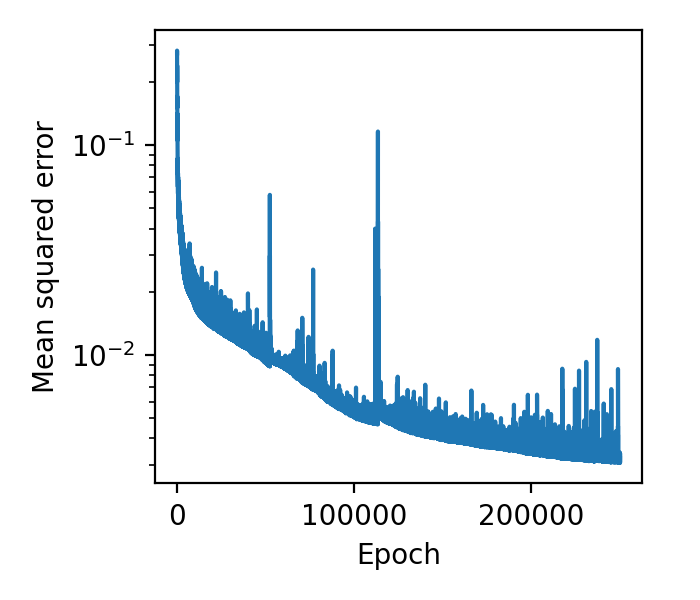

In [ ]:
plt.figure(figsize=(3.5,3))
plt.semilogy(loss_list)
plt.xlabel('Epoch')
plt.ylabel('Mean squared error')
plt.tight_layout()
plt.savefig('figs/loss.pdf')

In [ ]:
#np.save('results/w_rec', w)
#np.save('results/w_in', w_in.detach().numpy())

In [ ]:
#np.save('results/w_in', w_in.detach().numpy())
#np.save('results/w_rec', w)

<IPython.core.display.Javascript object>


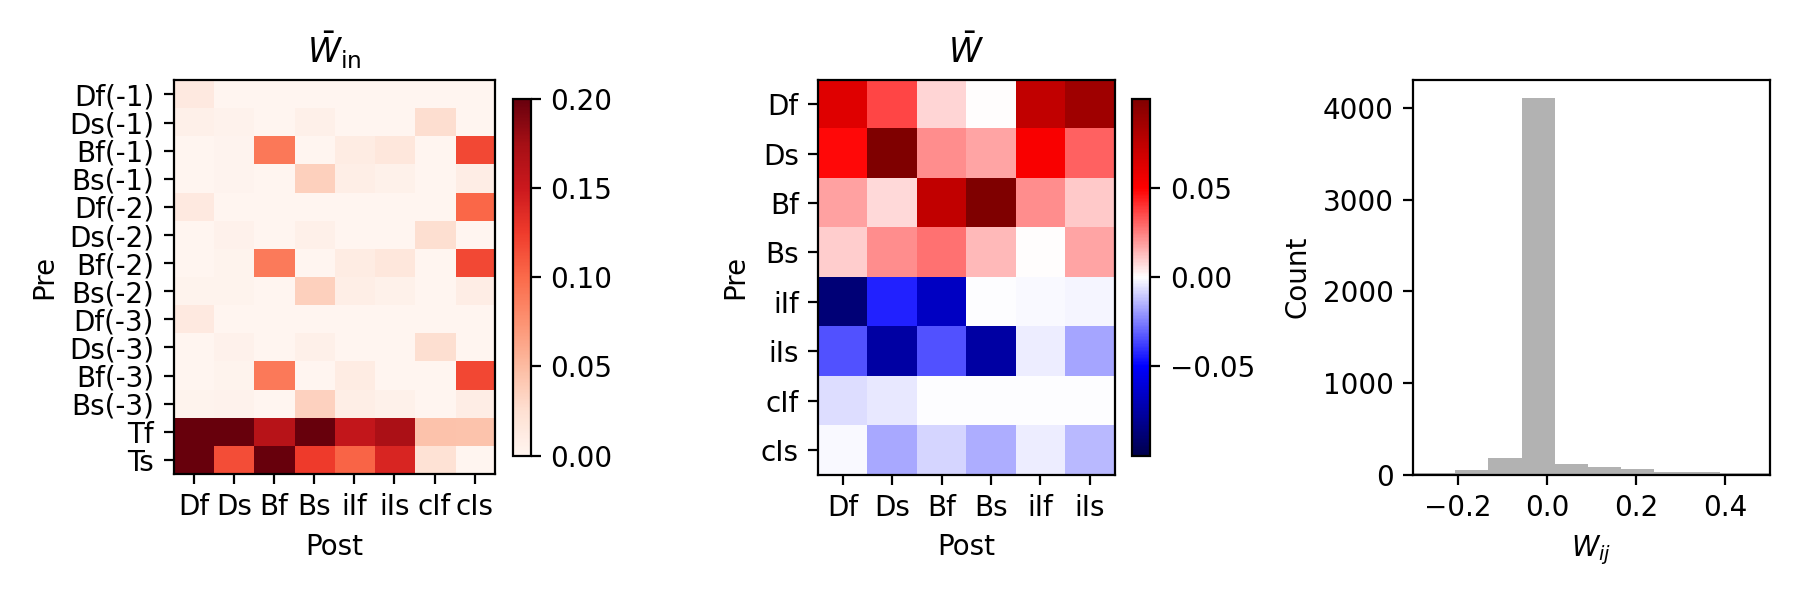

In [ ]:
# Look at the trained weight matrices.
from matplotlib.colors import TwoSlopeNorm

#w_in_avg_reduced = np.vstack((w_in_avg[0,:],
#                              np.mean(w_in_avg[1::2, :], axis=0),
#                              np.mean(w_in_avg[2::2, :], axis=0)))
w_in_avg_red = np.vstack((w_in_avg[:4*n_lags,:] + w_in_avg[4*n_lags:8*n_lags,:],
                          w_in_avg[-2:,:]))

plt.figure(figsize=(9,3))
plt.subplot(131)
#plt.imshow(1e-9 + w_in_avg_reduced, cmap='seismic', norm=TwoSlopeNorm(0, -1e-9, 0.2))
#plt.imshow(1e-9 + w_in_avg_reduced, cmap='Reds')
plt.imshow(1e-9 + w_in_avg_red, cmap='Reds', aspect=0.7)
#plt.yticks(np.arange(4), ['Df', 'Ds', 'Bf', 'Bs'])
#plt.yticks(np.arange(3), ['T', 'f', 's'])
plt.yticks(np.arange(4*n_lags+2),
           ['Df(-1)', 'Ds(-1)', 'Bf(-1)', 'Bs(-1)',
            'Df(-2)', 'Ds(-2)', 'Bf(-2)', 'Bs(-2)',
            'Df(-3)', 'Ds(-3)', 'Bf(-3)', 'Bs(-3)',
            'Tf', 'Ts'])
plt.xticks(np.arange(8), ['Df', 'Ds', 'Bf', 'Bs', 'iIf', 'iIs', 'cIf', 'cIs'])
plt.title('$\\bar{W}_\\mathrm{in}$')
plt.xlabel('Post')
plt.ylabel('Pre')
plt.colorbar(fraction=0.05)
plt.clim(0, 0.2)
plt.subplot(132)
#plt.imshow(w_avg * np.vstack((np.ones((4, 8)), -np.ones((4, 8)))))
plt.imshow(w_avg, cmap='seismic', norm=TwoSlopeNorm(0, -0.1, 0.1))
plt.title('$\\bar{W}$')
plt.xlabel('Post')
plt.ylabel('Pre')
plt.xticks(np.arange(6), ['Df', 'Ds', 'Bf', 'Bs', 'iIf', 'iIs'])
plt.yticks(np.arange(8), ['Df', 'Ds', 'Bf', 'Bs', 'iIf', 'iIs', 'cIf', 'cIs'])
plt.colorbar(fraction=0.05, ticks=[-0.05, 0, 0.05])
plt.subplot(133)
plt.hist(np.reshape(w, (-1)), bins=40, color='k', alpha=0.3);
plt.xlim(-0.3, 0.5)
plt.xlabel('$W_{ij}$')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figs/w_new.pdf')

<IPython.core.display.Javascript object>


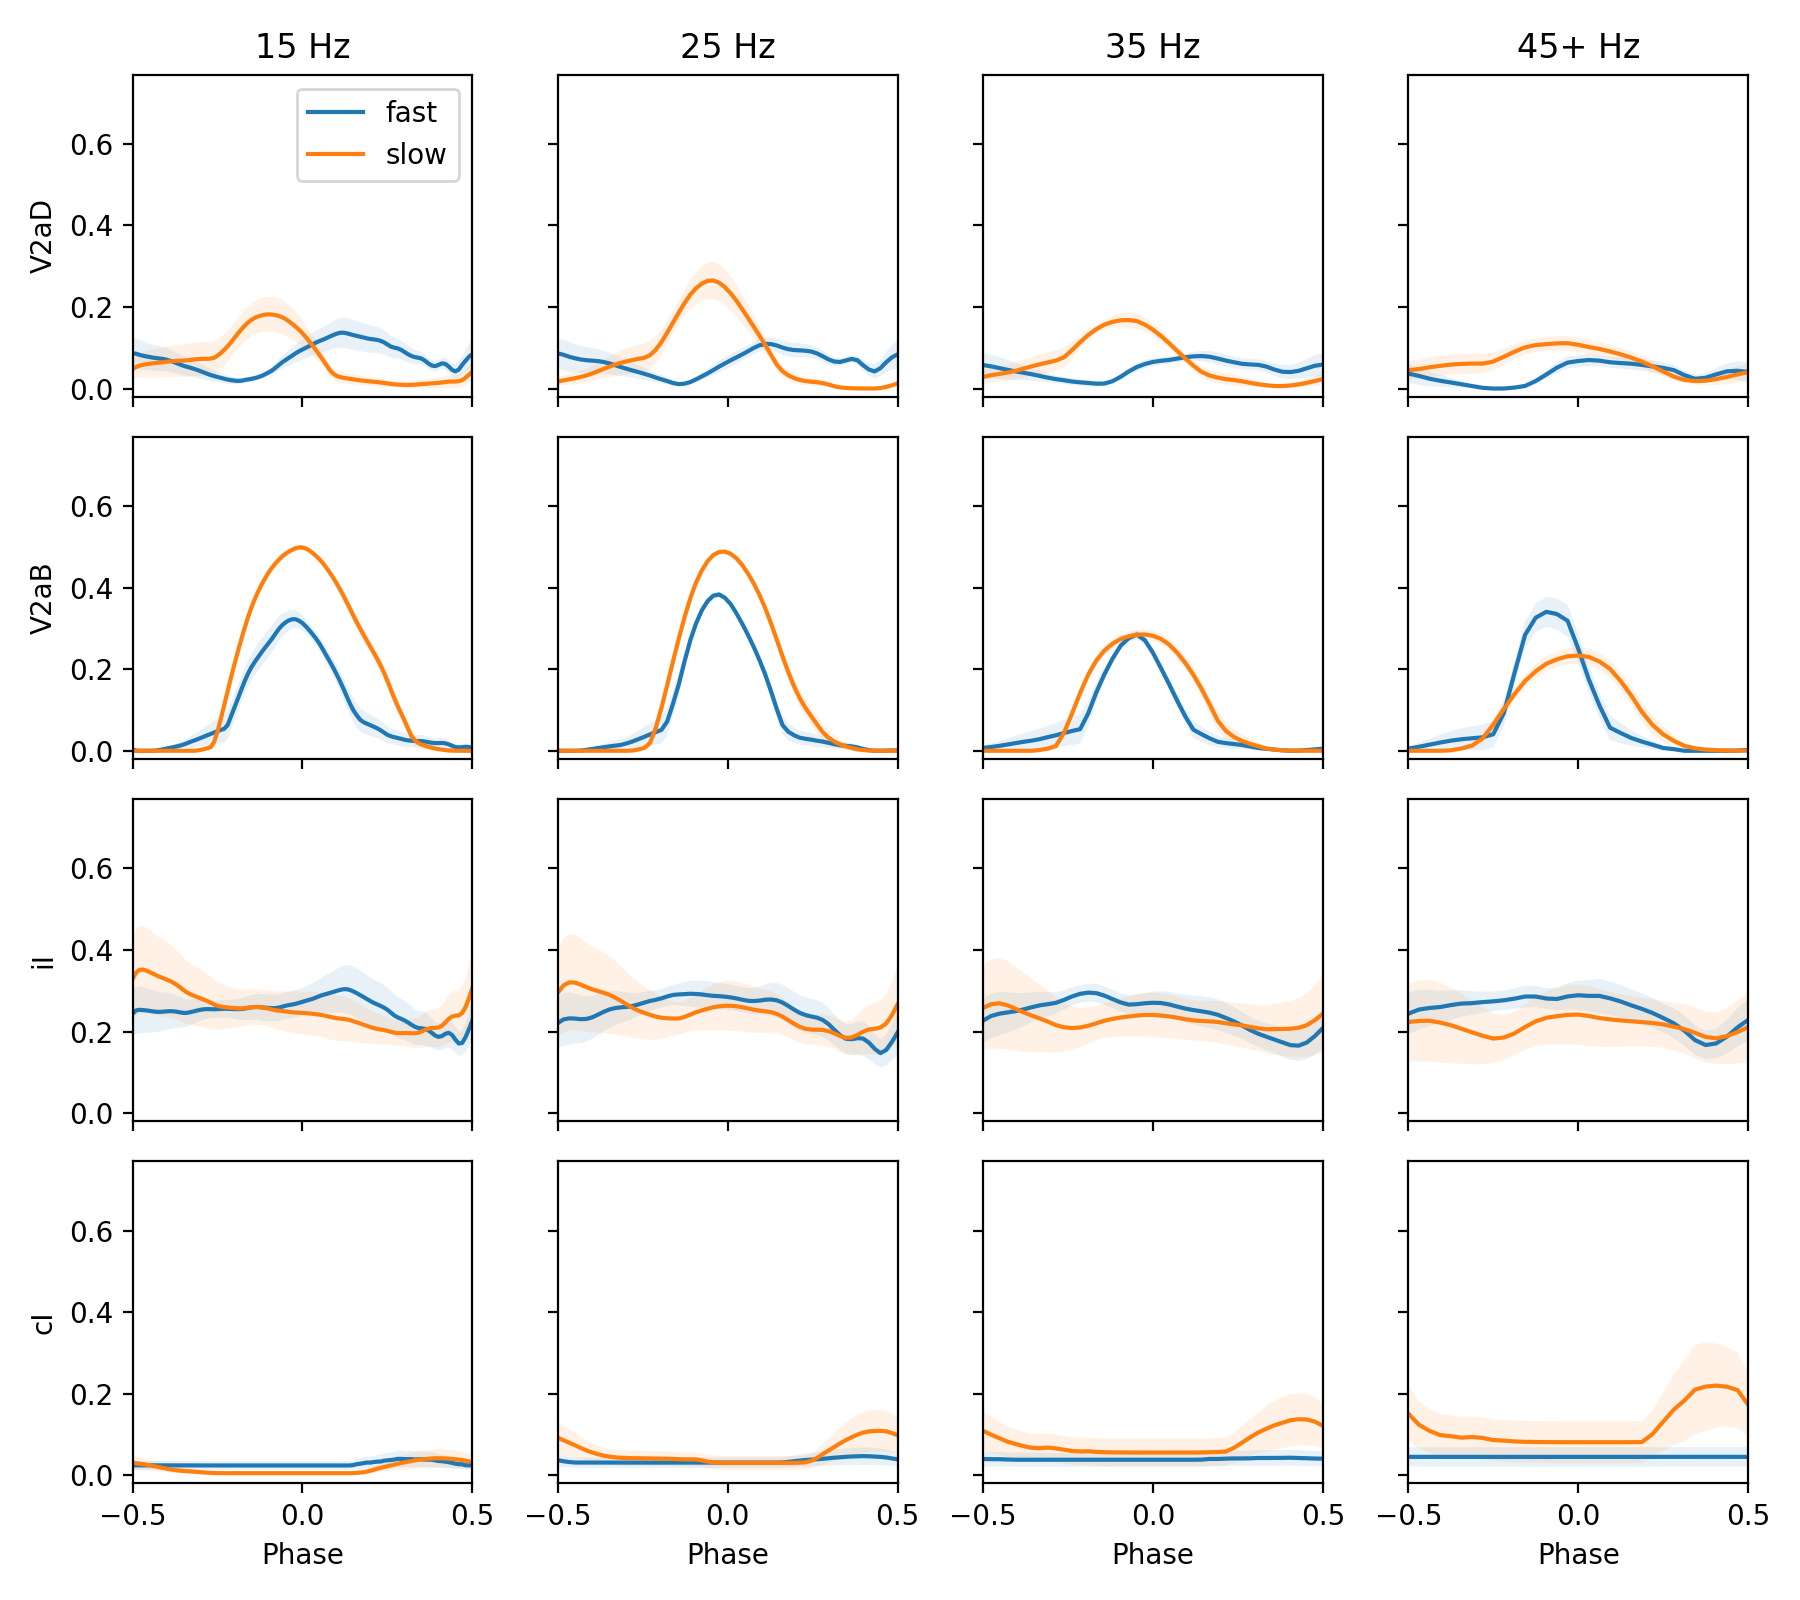

In [ ]:
plt.figure(figsize=(9,8))
plot_rates()
# plt.savefig('figs/rnn_rates.pdf')

In [ ]:
scores_all = {}
for i in range(4):
    s = np.load('results/scores_' + str(i) + '.npy', allow_pickle=True)
    s = s.item()
    for key in s.keys():
        if i == 0:
            scores_all[key] = [s[key]]
        else:
            scores_all[key].append(s[key])

from scipy import stats

for key in s.keys():
    #print(key, '\n', np.round(scores_all[key], 5))
    print(key, '\n p =', np.round(stats.ttest_1samp(scores_all[key], 0)[1], 4))

Intersegmental hierarchy (phasic) 
 p = 0.0003
Intersegmental hierarchy (tonic) 
 p = 0.0017
Ipsi-Inhibitory hierarchy (f) 
 p = 0.3967
Ipsi-Inhibitory hierarchy (s) 
 p = 0.034
Ipsi-Inhibitory modularity (f->s) 
 p = 0.0002
Ipsi-Inhibitory modularity (s->f) 
 p = 0.0248
Com-Inhibitory hierarchy (f) 
 p = 0.2213
Com-Inhibitory hierarchy (s) 
 p = 0.0052
Com-Inhibitory modularity (f->s) 
 p = 0.0381
Com-Inhibitory modularity (s->f) 
 p = 0.0016
Intrasegmental hierarchy 
 p = 0.1109
Recurrent hierarchy 
 p = 0.0085
Modularity 
 p = 0.001
Modular asymmetry 
 p = 0.0466


<IPython.core.display.Javascript object>


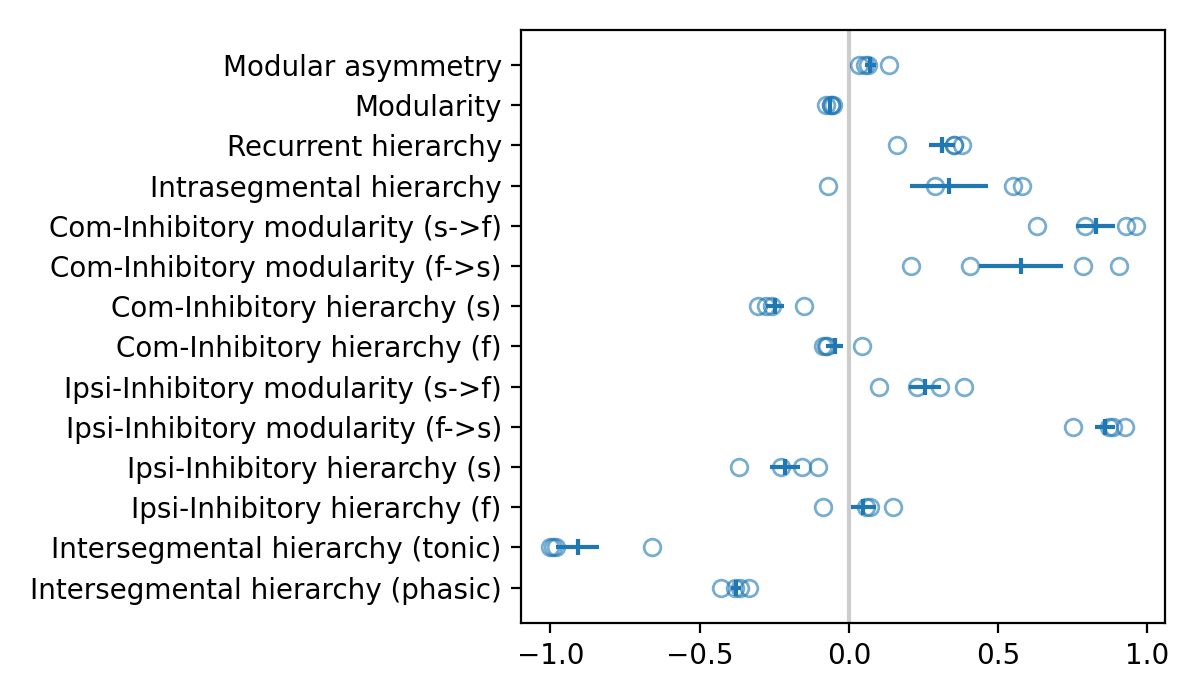

In [ ]:
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

plt.figure(figsize=(6, 3.5))
for i, key in enumerate(scores_all.keys()):
    plt.plot(scores_all[key], i * np.ones_like(scores_all[key]), 'o', color='tab:blue', fillstyle='none', alpha=0.6)
    plt.errorbar([np.mean(scores_all[key])], [i], xerr=np.std(scores_all[key])/len(scores_all[key])**0.5,
                 yerr=0.2, color='tab:blue')

plt.axvline(0, color='k', alpha=0.2)
plt.yticks(np.arange(len(scores_all.keys())), scores_all.keys())
plt.tight_layout()
plt.savefig('figs/scores_all.pdf')

<IPython.core.display.Javascript object>


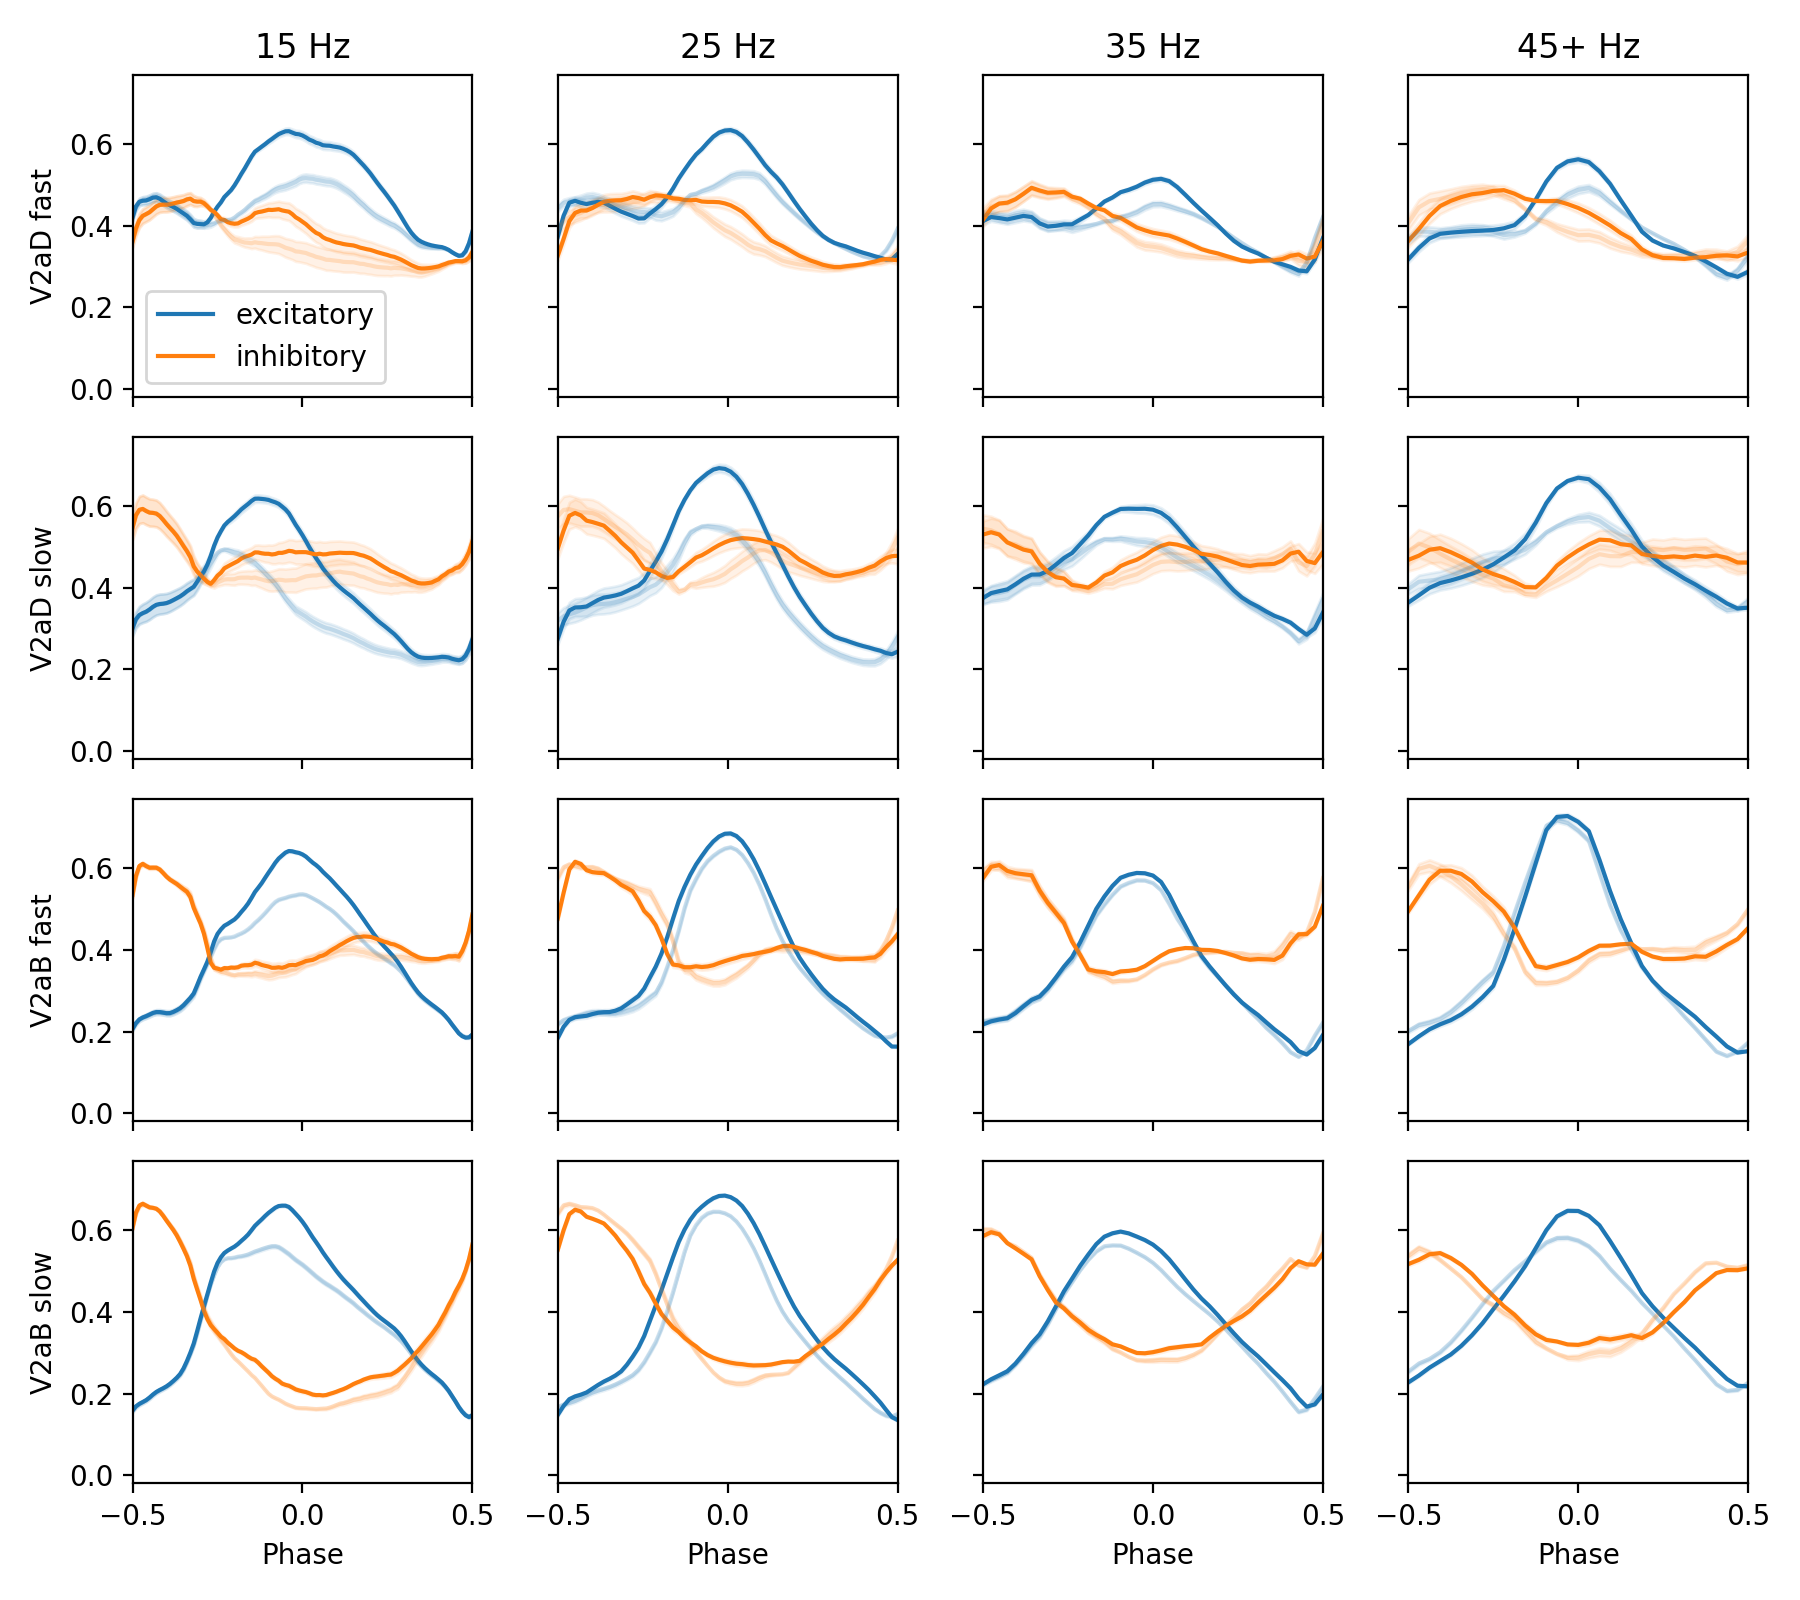

r-squared:  0.764251173076772
r-squared:  0.8456889480542789


In [ ]:
delta = 0.05

# Feedforward hierarchy perturbation:
w_in_pert_h = np.zeros_like(w_in)
w_in_pert_h[:4, 0*pop_size:2*pop_size] += delta
w_in_pert_h[:4, 2*pop_size:4*pop_size] -= delta

plt.figure(figsize=(9,8))
#plot_currents(w_given=torch.tensor(w - w_pert_h), alpha=0.2)
plot_currents(w_given=[torch.tensor(w), torch.tensor(w_in + w_in_pert_h)], alpha=1)
plot_currents(w_given=[torch.tensor(w), torch.tensor(w_in)], alpha=0.2)
plt.savefig('figs/rnn_currents_hffpert.pdf')

<IPython.core.display.Javascript object>


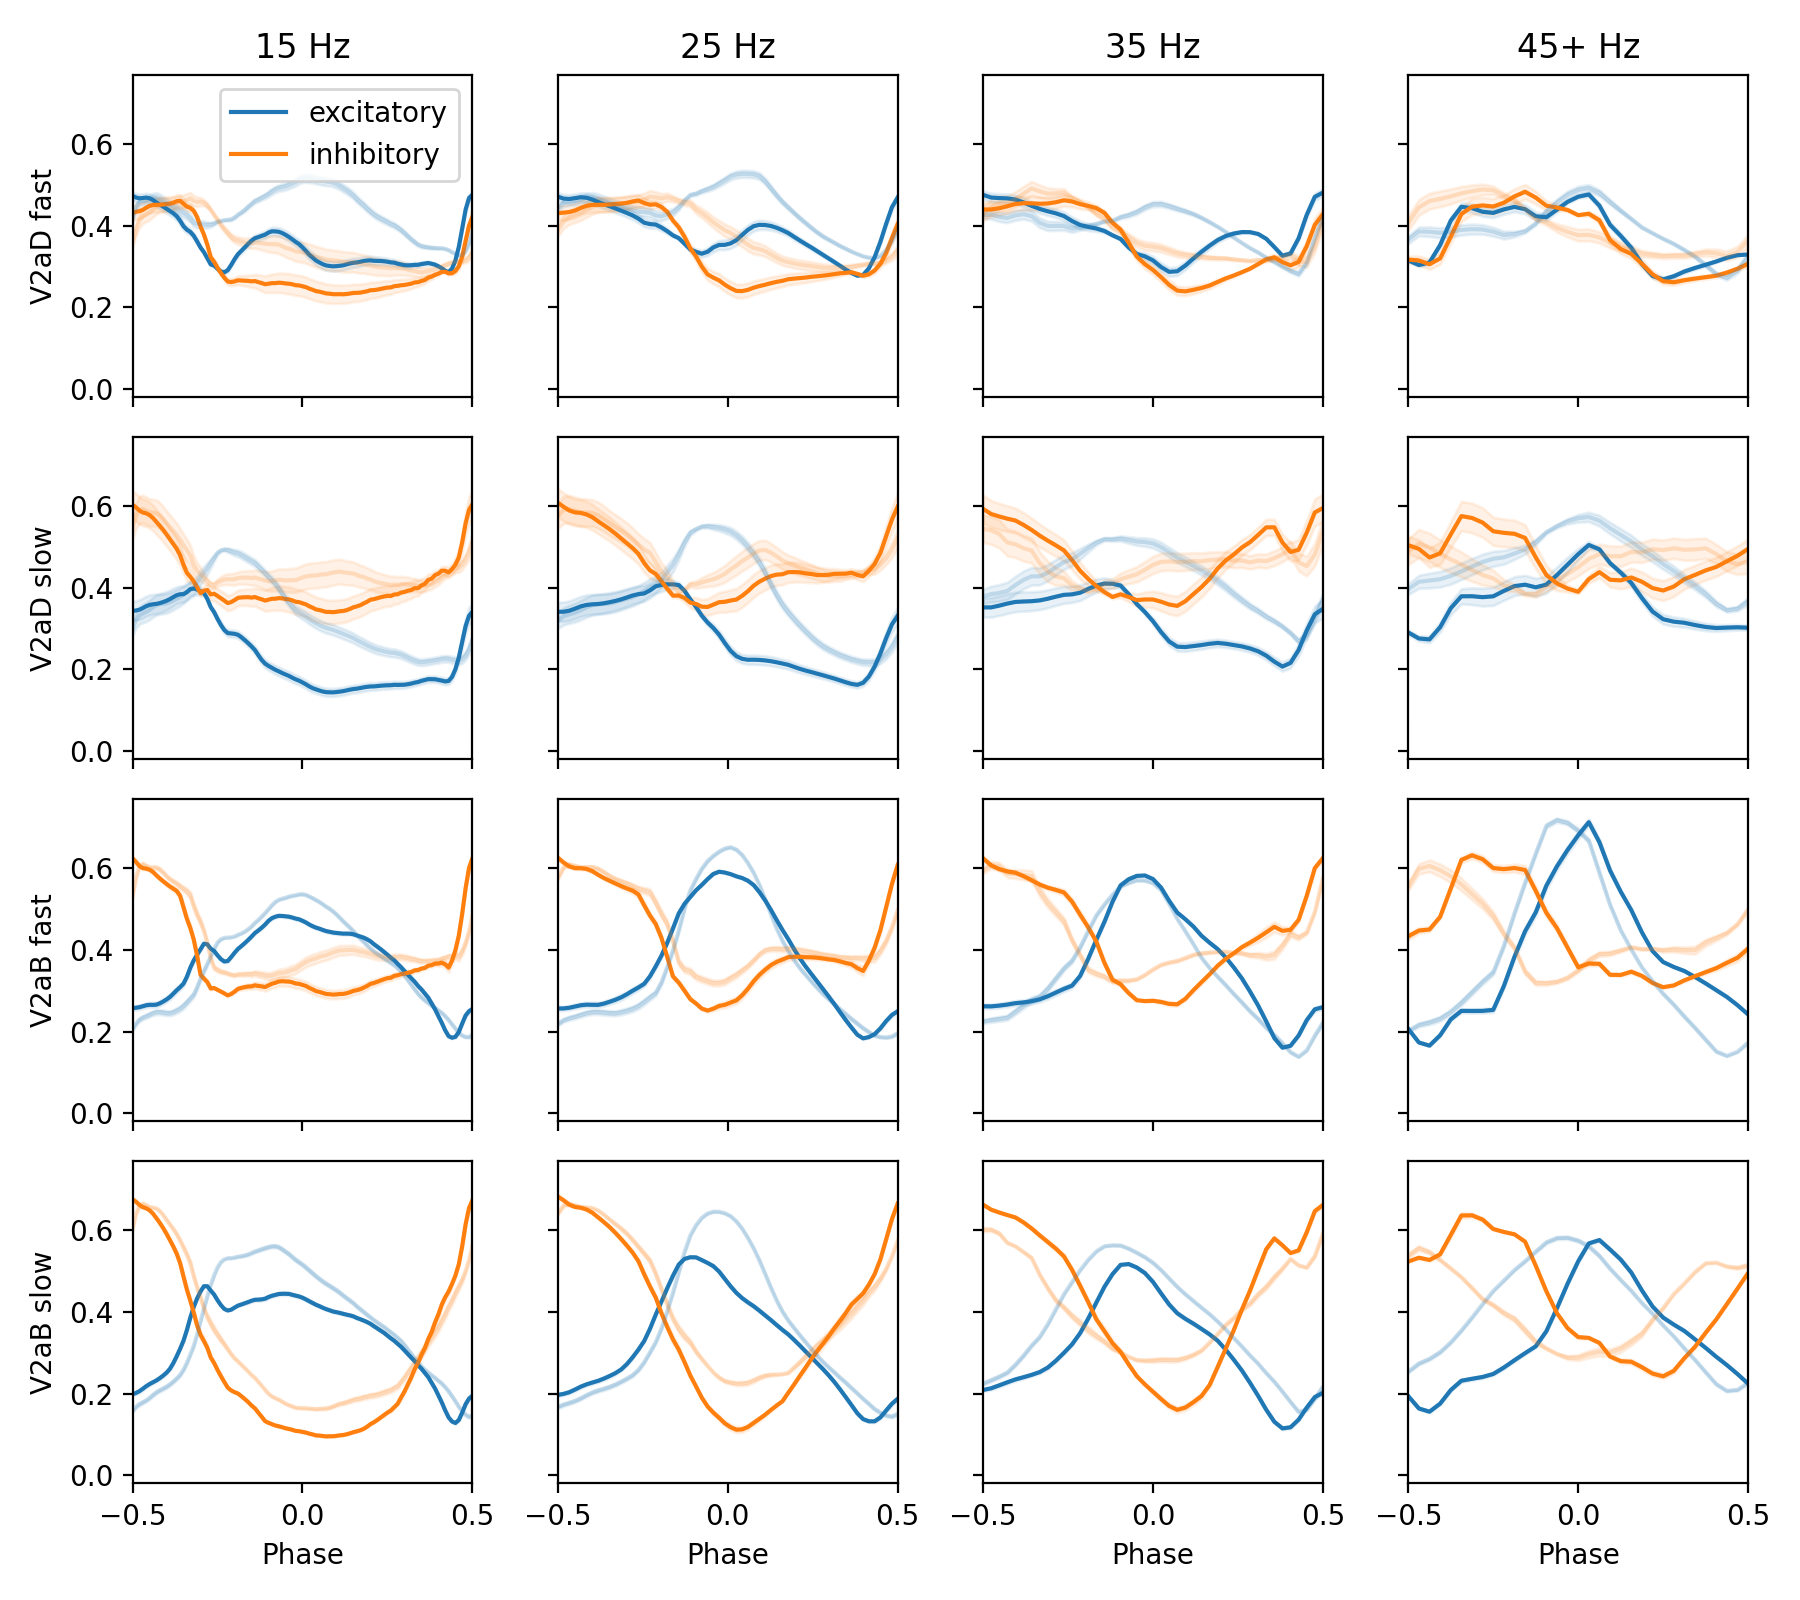

r-squared:  0.5314144769605231
r-squared:  0.8456889480542789


In [ ]:
delta = 0.005

# Hierarchy perturbation:
w_pert_h = np.zeros_like(w)
for (i,j) in [(0,2), (0,3), (1,2), (1,3)]:
    w_pert_h[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size] += delta
    w_pert_h[j*pop_size:(j+1)*pop_size, i*pop_size:(i+1)*pop_size] -= delta

plt.figure(figsize=(9,8))
#plot_currents(w_given=torch.tensor(w - w_pert_h), alpha=0.2)
plot_currents(w_given=[torch.tensor(w + w_pert_h), torch.tensor(w_in)], alpha=1)
plot_currents(w_given=[torch.tensor(w), torch.tensor(w_in)], alpha=0.2)
plt.savefig('figs/rnn_currents_hrecpert.pdf')

<IPython.core.display.Javascript object>


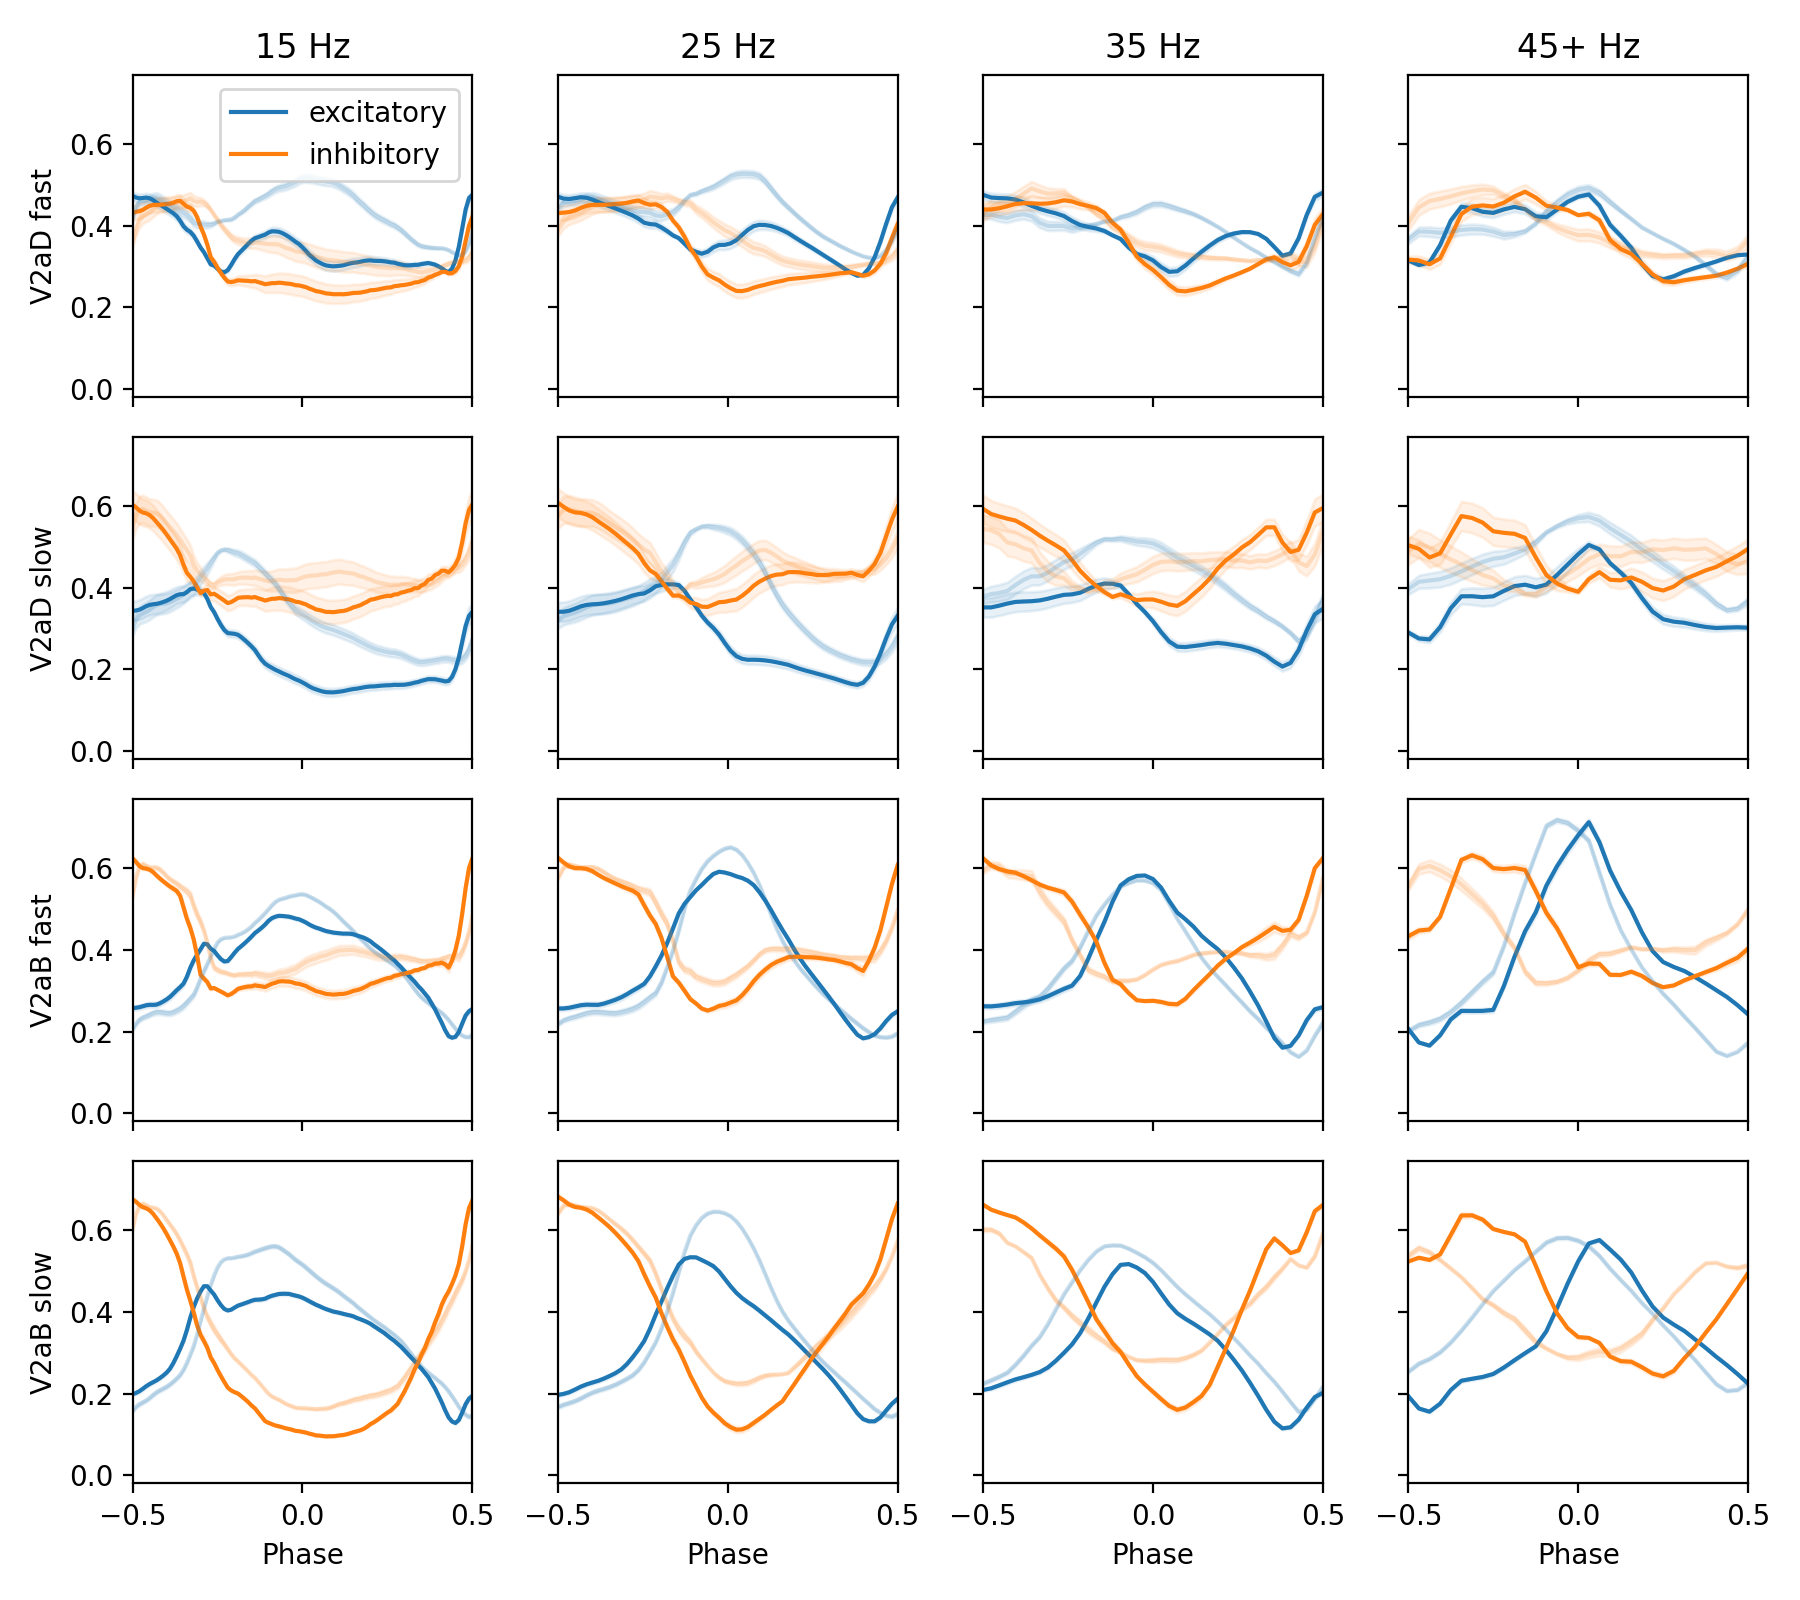

r-squared:  0.5314144769605231
r-squared:  0.8456889480542789


In [ ]:
delta = 0.002

# Modularity perturbation:
w_pert_m = np.zeros_like(w)
#for (i,j) in [(0,1), (0,3), (2,1), (2,3)]:
#    w_pert_m[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size] -= delta
#    w_pert_m[j*pop_size:(j+1)*pop_size, i*pop_size:(i+1)*pop_size] -= delta
for (i,j) in [(0,0), (2,2), (0,2), (2,0)]:
    w_pert_m[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size] += delta
for (i,j) in [(1,1), (3,3), (1,3), (3,1)]:
    w_pert_m[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size] += delta

plt.figure(figsize=(9,8))
#plot_currents(w_given=torch.tensor(w - w_pert_m), alpha=0.2)
plot_currents(w_given=[torch.tensor(w + w_pert_h), torch.tensor(w_in)], alpha=1)
plot_currents(w_given=[torch.tensor(w), torch.tensor(w_in)], alpha=0.2)
plt.savefig('figs/rnn_currents_mpert.pdf')

<IPython.core.display.Javascript object>


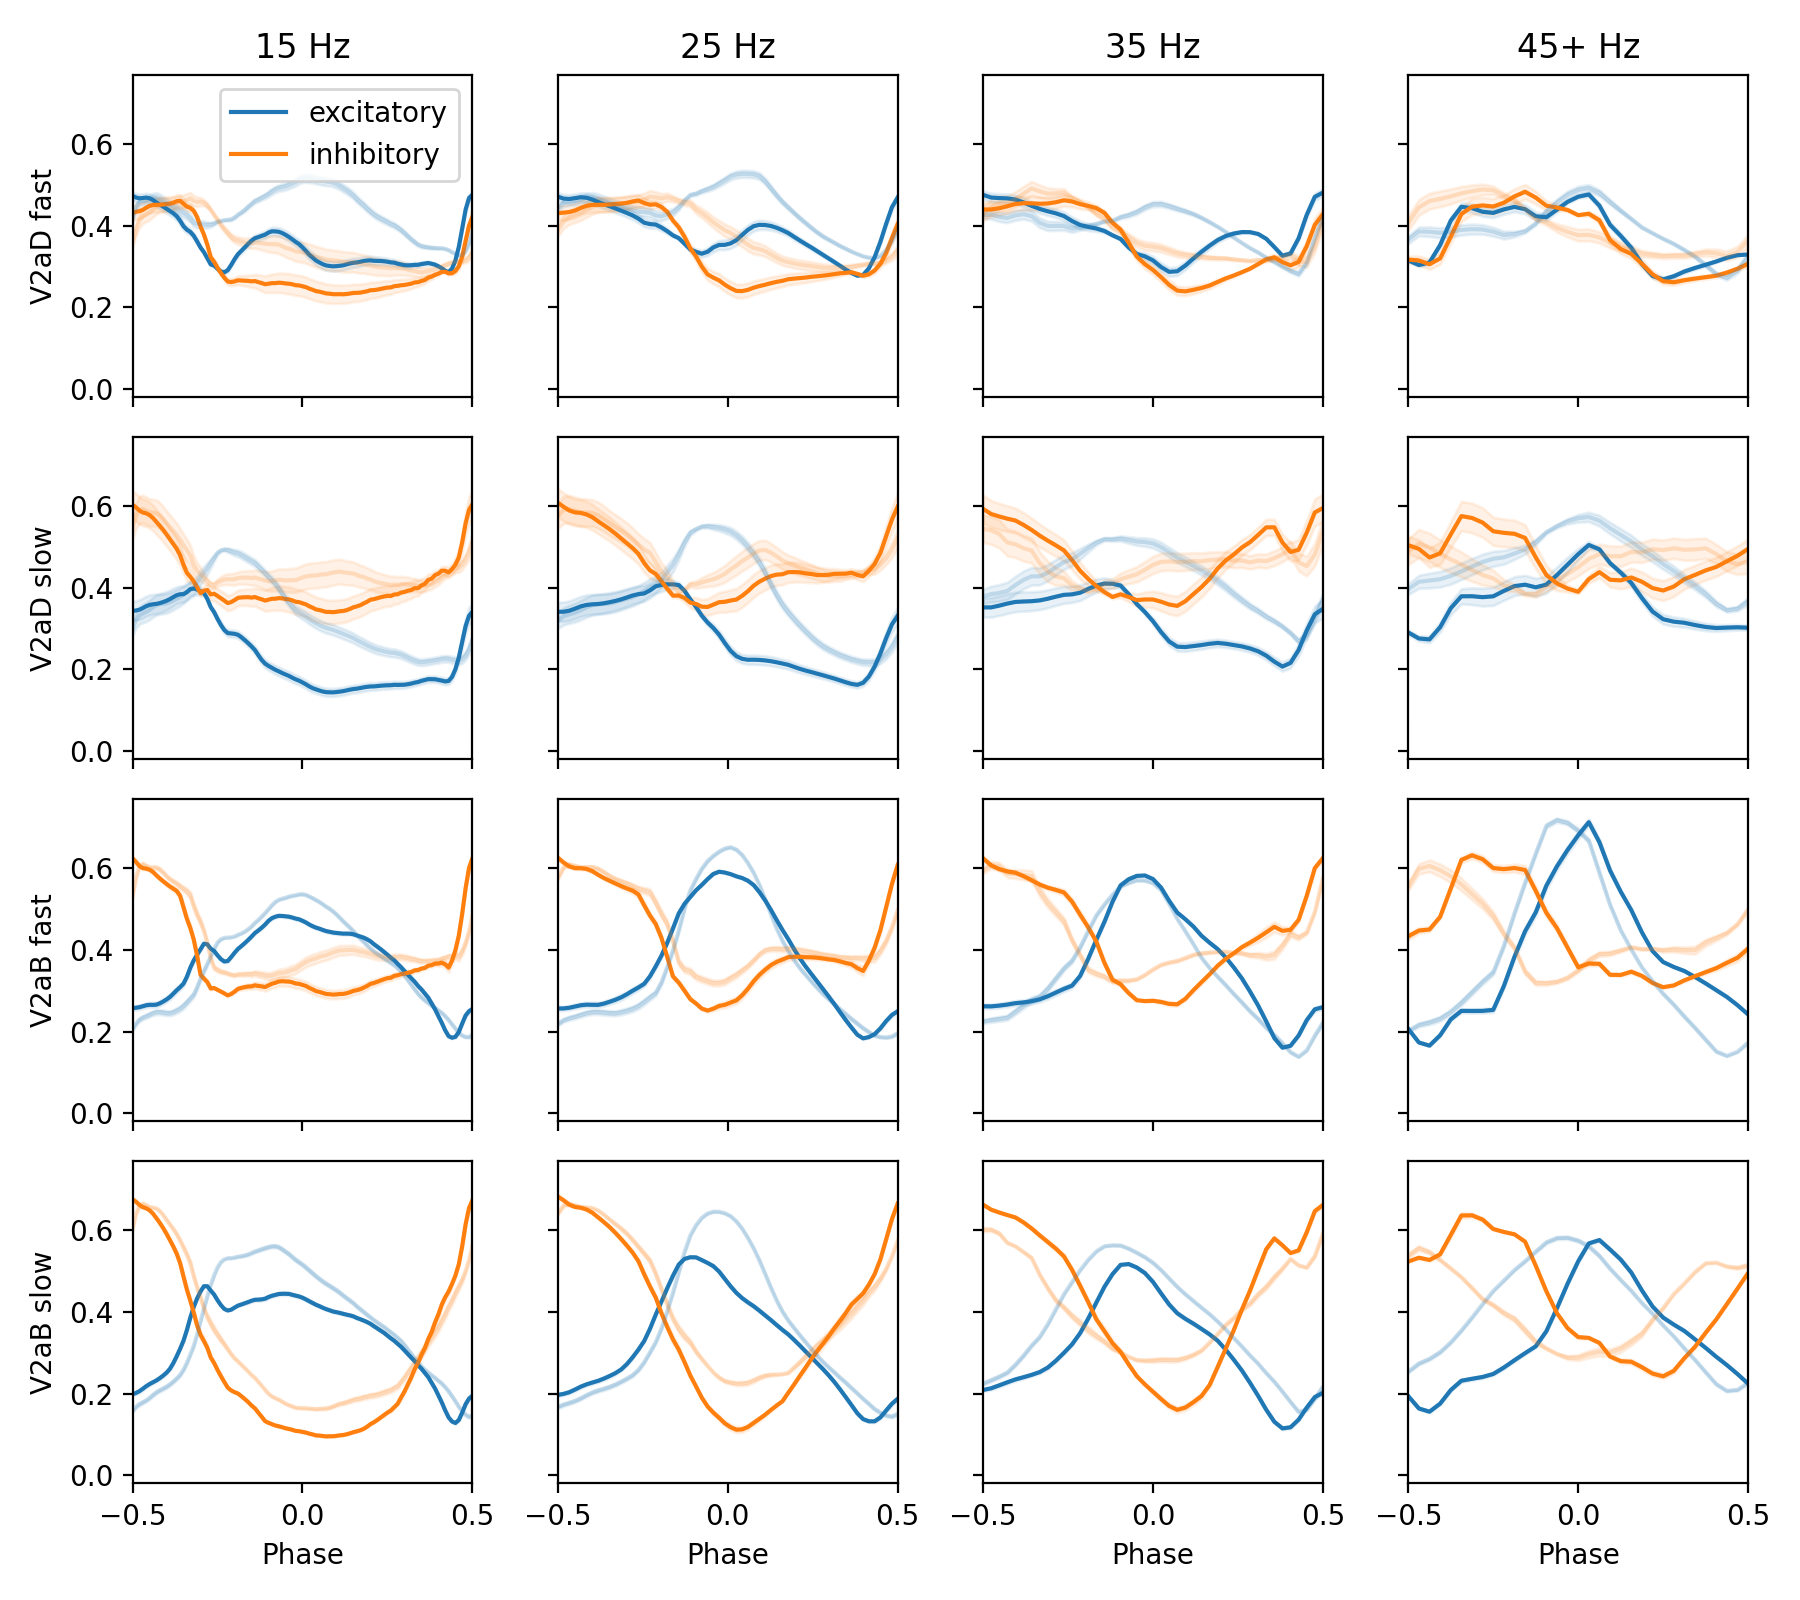

r-squared:  0.5314144769605231
r-squared:  0.8456889480542789


In [ ]:
delta = 0.002

# Modular asymmetry perturbation:
w_pert_ma = np.zeros_like(w)
for (i,j) in [(0,1), (0,3), (2,1), (2,3)]:
    w_pert_ma[i*pop_size:(i+1)*pop_size, j*pop_size:(j+1)*pop_size] += delta
    #w_pert_ma[j*pop_size:(j+1)*pop_size, i*pop_size:(i+1)*pop_size] -= delta

plt.figure(figsize=(9,8))
#plot_currents(w_given=torch.tensor(w - w_pert_ma), alpha=0.2)
plot_currents(w_given=[torch.tensor(w + w_pert_h), torch.tensor(w_in)], alpha=1)
plot_currents(w_given=[torch.tensor(w), torch.tensor(w_in)], alpha=0.2)
plt.savefig('figs/rnn_currents_mapert.pdf')

# Misc

In [ ]:
# Functions to make up some fake data:

def wiggles(n_harmonics=3):
    c = torch.randn(n_harmonics)  # Fourier amplitudes
    f = torch.tensor(np.arange(1, len(c) + 1))  # harmonic frequencies
    trace = torch.stack([torch.randn(1) *
                         torch.sin(2 * torch.pi * f[i] * torch.linspace(0, 1, n_timesteps)) for i in range(n_harmonics)])
    trace = torch.sum(trace, axis=0)
    trace *= torch.exp(-0.5 * (torch.linspace(0, 1, n_timesteps) - 0.5)**2 / 0.2**2)
    return trace

def get_xy(period):
    '''
    Get fake-data inputs and target outputs.

    Inputs
    --
    period : integer giving the number of timesteps in each period (should be a divisor of n_timesteps).

    Returns
    --
    x, y : 2D arrays giving the fake-data input and output, with n_timesteps time points in each.
    '''
    x_timewarped = torch.stack([wiggles() for i in range(n_inputs)]).T
    y_timewarped = torch.stack([wiggles() for i in range(n_outputs)]).T

    x = torch.cat([x_timewarped for i in range(n_timesteps//period)])[::n_timesteps//period]
    y = torch.cat([y_timewarped for i in range(n_timesteps//period)])[::n_timesteps//period]

    return x, y

x_list, y_list = [], []
for period in periods:
    x_p, y_p = get_xy(period)
    x_list.append(x_p)
    y_list.append(y_p)

# Define inputs and target outputs:
if False:
    x, y = [], []
    for i in range(n_inputs):
        x.append(torch.sin(2 * torch.pi * 5 * torch.rand(1) * torch.linspace(0, 1, n_timesteps)))
    x = torch.stack(x).T
    for i in range(n_outputs):
        y.append(torch.sin(2 * torch.pi * 5 * torch.rand(1) * torch.linspace(0, 1, n_timesteps)))
    y = torch.stack(y).T


In [ ]:
learning_rate = 3e-4
n_epochs = 20000
l2_regs = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
losses = np.zeros(len(l2_regs))
w_norms = np.zeros(len(l2_regs))
scores = np.zeros((len(l2_regs), 3))
for i, l2_reg in enumerate(l2_regs):
    print('L2 regularization: ', l2_reg)
    loss, score, w_norm = train_rnn(learning_rate, l2_reg, n_epochs)
    losses[i] = loss
    scores[i,:] = score
    w_norms[i] = w_norm

L2 regularization:  0
Epoch:  2000 / 20000 	 Loss:  0.039617255
Epoch:  4000 / 20000 	 Loss:  0.01863247
Epoch:  6000 / 20000 	 Loss:  0.009278628
Epoch:  8000 / 20000 	 Loss:  0.0063523618
Epoch:  10000 / 20000 	 Loss:  0.0051271007
Epoch:  12000 / 20000 	 Loss:  0.0044134883
Epoch:  14000 / 20000 	 Loss:  0.004162253
Epoch:  16000 / 20000 	 Loss:  0.0038127608
Epoch:  18000 / 20000 	 Loss:  0.003479261
Epoch:  20000 / 20000 	 Loss:  0.0031577162
Weight norm:  3.6501932
Hierarchy score:  0.2451663
Modularity score:  0.025561823
Modular asymmetry score:  0.030124875


ValueError: setting an array element with a sequence.

<IPython.core.display.Javascript object>


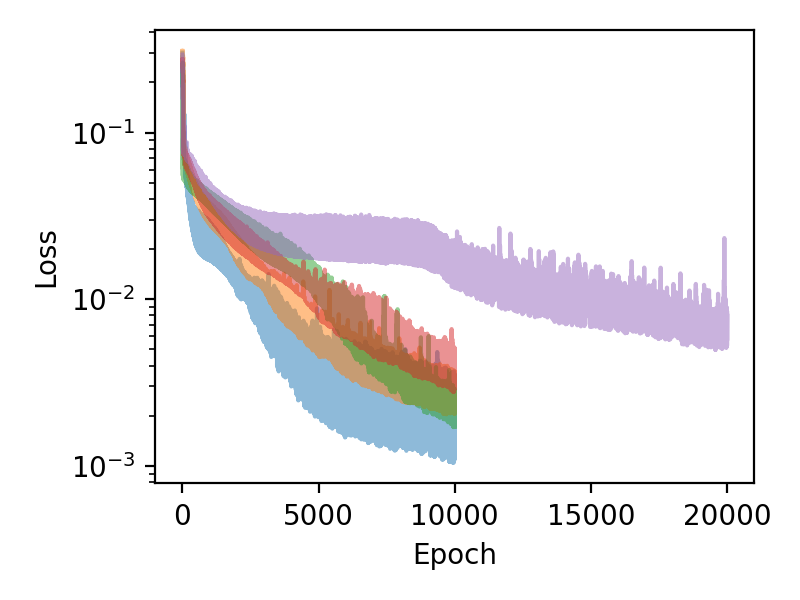

In [ ]:
plt.figure(figsize=(4,3))
#loss_list0 = loss_list  # Baseline
#loss_list1 = loss_list  # Includes variance penalty among units within each population
#loss_list2 = loss_list  # Includes nonzero recurrent weight initialization
#loss_list3 = loss_list  # Reduces pop_size from 10 to 5
loss_list4 = loss_list  # All input weights are excitatory; excitatory input currents include external input
plt.semilogy(loss_list0, alpha=0.5)
plt.semilogy(loss_list1, alpha=0.5)
plt.semilogy(loss_list2, alpha=0.5)
plt.semilogy(loss_list3, alpha=0.5)
plt.semilogy(loss_list4, alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()

<IPython.core.display.Javascript object>


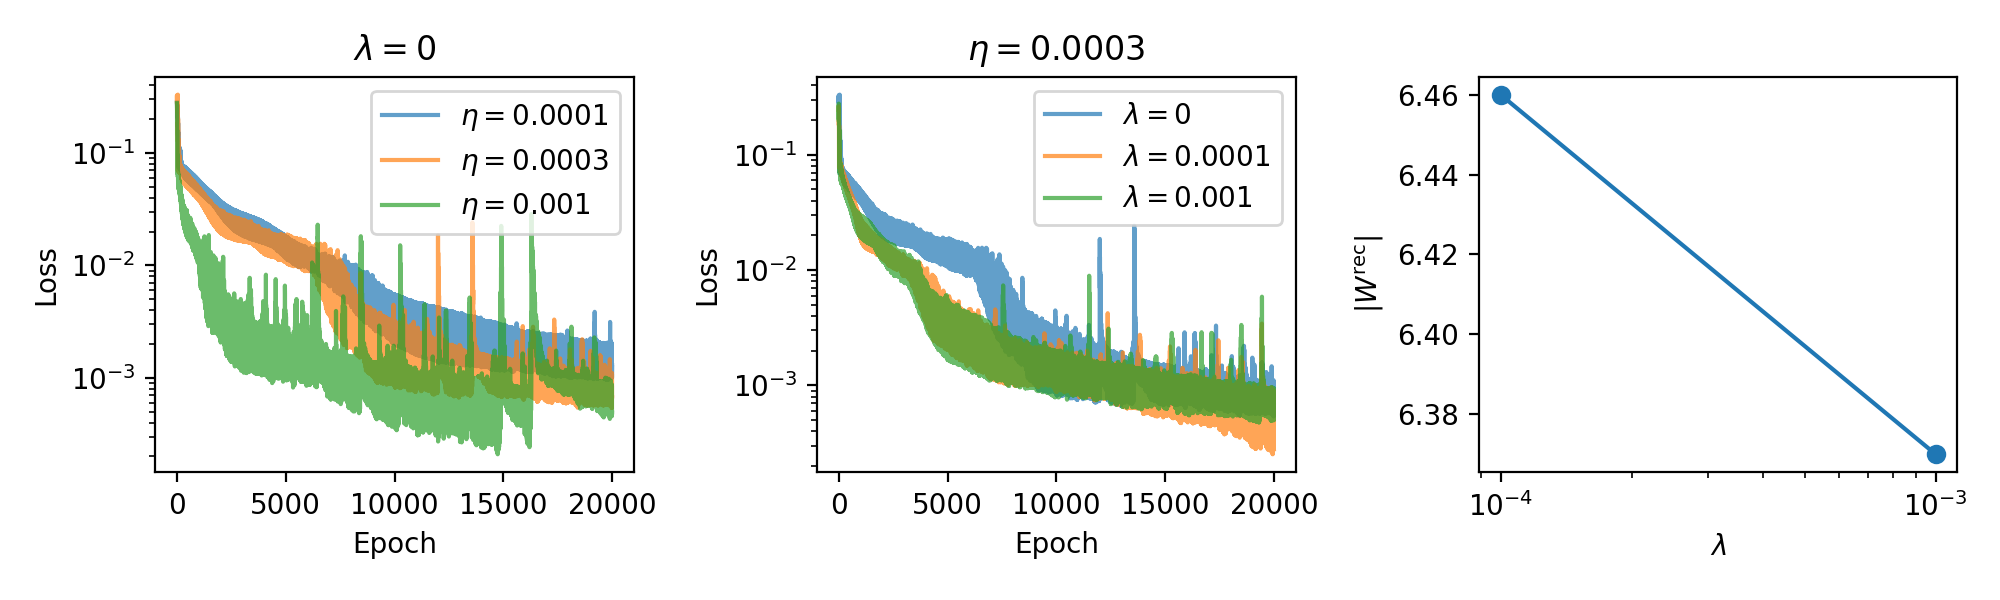

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(131)
plt.semilogy(losses0.T, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['$\eta = $' + str(lr) for lr in learning_rates])
plt.title('$\\lambda = 0$')

plt.subplot(132)
plt.semilogy(losses[:3,:].T, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['$\\lambda = $' + str(l2_reg) for l2_reg in l2_regs[:3]])
plt.title('$\eta = 0.0003$')

plt.subplot(133)
plt.semilogx(l2_regs[1:3], weight_norms[1:], '-o')
plt.xlabel('$\\lambda$')
plt.ylabel('$|W^\\mathrm{rec}|$')

plt.tight_layout()
plt.savefig('figs/loss.pdf')

In [ ]:
# SVD analysis of the connectivity matrix.

u, s, vh = np.linalg.svd(w_avg, full_matrices=False)
print('Singlular values: ', s)
w0 = np.outer(u[:,0], vh[0,:])
w1 = np.outer(u[:,1], vh[1,:])
print(np.round(w0, 2))
print('\n', np.round(w1, 2))

Singlular values:  [0.49027084 0.13927523 0.08587464 0.06363745 0.05609054 0.04731241
 0.02811094 0.00308031]
[[ 0.17  0.2   0.16  0.13  0.26  0.15  0.25  0.28]
 [ 0.1   0.12  0.09  0.08  0.15  0.09  0.15  0.16]
 [ 0.06  0.07  0.06  0.05  0.09  0.05  0.09  0.1 ]
 [ 0.04  0.05  0.04  0.03  0.07  0.04  0.07  0.07]
 [-0.09 -0.1  -0.08 -0.07 -0.13 -0.08 -0.13 -0.14]
 [-0.09 -0.1  -0.08 -0.07 -0.14 -0.08 -0.13 -0.15]
 [-0.13 -0.15 -0.12 -0.1  -0.19 -0.11 -0.19 -0.21]
 [-0.09 -0.11 -0.09 -0.07 -0.14 -0.08 -0.14 -0.15]]

 [[ 0.08 -0.18  0.02 -0.16 -0.08 -0.01  0.19  0.05]
 [-0.08  0.2  -0.02  0.17  0.09  0.01 -0.21 -0.06]
 [ 0.03 -0.08  0.01 -0.07 -0.04 -0.    0.08  0.02]
 [ 0.01 -0.03  0.   -0.02 -0.01 -0.    0.03  0.01]
 [-0.15  0.35 -0.03  0.3   0.16  0.01 -0.37 -0.1 ]
 [ 0.04 -0.09  0.01 -0.08 -0.04 -0.    0.1   0.03]
 [ 0.12 -0.29  0.03 -0.25 -0.13 -0.01  0.31  0.09]
 [ 0.01 -0.03  0.   -0.03 -0.01 -0.    0.03  0.01]]


In [ ]:
drive_to_des = np.mean(w_in_avg[:4, 0:2])
drive_to_bif = np.mean(w_in_avg[:4, 2:4])
hierarchy_ff_score = (drive_to_des - drive_to_bif) / (drive_to_des + drive_to_bif)
print('Feedforward hierarchy score: ', hierarchy_ff_score)

des_to_bif = np.mean([w_avg[0:1, 2:3],
                      w_avg[0:1, 3:4],
                      w_avg[1:2, 2:3],
                      w_avg[1:2, 3:4]])
bif_to_des = np.mean([w_avg[2:3, 0:1],
                      w_avg[3:4, 0:1],
                      w_avg[2:3, 1:2],
                      w_avg[3:4, 1:2]])
hierarchy_score = (des_to_bif - bif_to_des) / (des_to_bif + bif_to_des)
print('Recurrent hierarchy score: ', hierarchy_score)

f_to_s = np.mean([w_avg[0:1, 1:2],
                  w_avg[0:1, 3:4],
                  w_avg[2:3, 1:2],
                  w_avg[2:3, 3:4]])
s_to_f = np.mean([w_avg[1:2, 0:1],
                  w_avg[3:4, 0:1],
                  w_avg[1:2, 2:3],
                  w_avg[3:4, 2:3]])
f_to_f = np.mean([w_avg[0:1, 0:1],
                  w_avg[2:3, 2:3],
                  w_avg[0:1, 2:3],
                  w_avg[2:3, 0:1]])
s_to_s = np.mean([w_avg[1:2, 1:2],
                  w_avg[3:4, 3:4],
                  w_avg[1:2, 3:4],
                  w_avg[3:4, 1:2]])
modularity_score = (f_to_f + s_to_s - f_to_s - s_to_f) / (f_to_f + s_to_s + f_to_s + s_to_f)
print('Modularity score: ', modularity_score)
modular_asymmetry_score = (f_to_s - s_to_f) / (f_to_s + s_to_f)
print('Modular asymmetry score: ', modular_asymmetry_score)
scores = [hierarchy_score, modularity_score, modular_asymmetry_score]



Feedforward hierarchy score:  -0.7248051326955782
Recurrent hierarchy score:  0.936056257895859
Modularity score:  0.41857029636750676
Modular asymmetry score:  0.11193124001163274


In [ ]:
if False:
    scores = {}
    for i in range(4):
        s = np.load('results/scores_' + str(i) + '.npy', allow_pickle=True)
        s = s.item()
        for key in s.keys():
            if i == 0:
                if type(s[key]) == np.ndarray:
                    scores[key] = [s[key][-1]]
                else:
                    scores[key] = [s[key]]
            else:
                if type(s[key]) == np.ndarray:
                    scores[key].append(s[key][-1])
                else:
                    scores[key].append(s[key])

    for key in s.keys():
        print(key, '\n', scores[key])

FF Hierarchy 
 [-0.7313483585758096, -0.9084692784058447, -0.885613946455287, -0.460672774737639]
Ipsi-Inhibitory hierarchy 
 [-0.05060881202972559, -0.08895282992945441, -0.15915962091026895, 0.11841790049183028]
Ipsi-Inhibitory modularity 
 [-0.07506431645772192, 0.0015949990544265517, -0.2270530950460035, 0.2092993633447178]
Com-Inhibitory hierarchy 
 [0.3381243380711788, 0.47575528687570867, 0.2883402059718908, 0.47977308222429366]
Com-Inhibitory modularity 
 [-0.3475734377687259, -0.0870713235779313, -0.15482551471577208, -0.14117268738916644]
Rec hierarchy 
 [0.9027962838637439, 0.05211372901996577, 0.8811793695369036, 0.828079601431176]
Modularity 
 [0.371216795211663, 0.3217827052513546, 0.3255775152220622, 0.39635654156909345]
Modular asymmetry 
 [0.6534778352954353, 0.638550617222351, 0.26134847299414266, 0.33604815059917026]


<IPython.core.display.Javascript object>


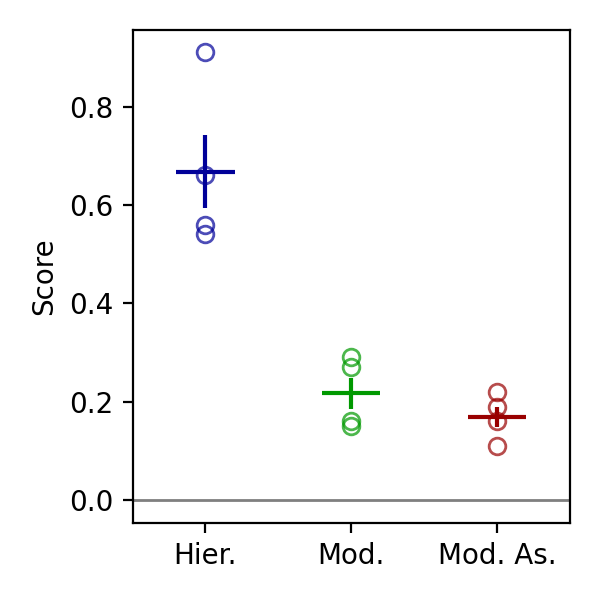

In [ ]:
#scores = np.load('results/scores.npy')
#scores = np.random.rand(5, 3)
#scores = np.array([[0.45, 0.10, 0.11],  # without L1 regularization
#                   [0.46, 0.10, 0.052],
#                   [0.353, 0.067, 0.080],
#                   [0.40, 0.035, 0.10],
#                   [0.47, 0.15, 0.18]])
scores = np.array([[0.54, 0.29, 0.19],  # with L1 regularization
                   [0.66, 0.15, 0.22],
                   [0.91, 0.27, 0.11],
                   [0.56, 0.16, 0.16]])

plt.figure(figsize=(3,3))
colors = [(0, 0, 0.6), (0, 0.6, 0), (0.6, 0, 0)]
for i in [0,1,2]:
    plt.plot(i*np.ones(len(scores)), scores[:, i], 'o', color=colors[i], fillstyle='none', alpha=0.7)
    plt.errorbar([i], [np.mean(scores[:,i])], xerr=0.2, yerr=np.std(scores[:,i])/len(scores)**0.5, color=colors[i])
plt.xticks(np.arange(3), ['Hier.', 'Mod.', 'Mod. As.'])
plt.axhline(0, color='tab:gray', lw=1)
#plt.ylim(-1.05, 1.05)
plt.xlim(-0.5, 2.5)
plt.ylabel('Score')
plt.tight_layout()
#plt.savefig('figs/scores_lam1e-5.pdf')

In [ ]:
bias_avg = np.zeros(n_pops)
for i in range(n_pops):
    bias_avg[i] = np.mean(bias.detach().numpy()[i*pop_size:(i+1)*pop_size])
    print(['Df', 'Ds', 'Bf', 'Bs', 'iIf', 'iIs', 'cIf', 'cIs'][i], '\t', bias_avg[i])

Df 	 0.24047860503196716
Ds 	 0.25983569025993347
Bf 	 0.21044227480888367
Bs 	 0.21175162494182587
iIf 	 0.023192517459392548
iIs 	 0.07955849915742874
cIf 	 0.028091218322515488
cIs 	 0.013704894110560417


In [ ]:
scores = {}
scores['FF Hierarchy'] = (np.sum(w_in_avg[:4, :2]) - np.sum(w_in_avg[:4, 2:4])) \
                         / (np.sum(w_in_avg[:4, :2]) + np.sum(w_in_avg[:4, 2:4]))
scores['Ipsi-Inhibitory hierarchy'] = np.array([(w_avg[4,0] - w_avg[4,2]) / (w_avg[4,0] + w_avg[4,2]),
                                       (w_avg[5,1] - w_avg[5,3]) / (w_avg[5,1] + w_avg[5,3]),
                                       (w_avg[4,0] + w_avg[5,1] - w_avg[4,2] - w_avg[5,3])
                                       / (w_avg[4,0] + w_avg[5,1] + w_avg[4,2] + w_avg[5,3])])
scores['Ipsi-Inhibitory modularity'] = np.array([(w_avg[5,2] - w_avg[5,0]) / (w_avg[5,2] + w_avg[5,0]),
                                       (w_avg[4,1] - w_avg[4,3]) / (w_avg[4,1] + w_avg[4,3]),
                                       (w_avg[5,0] + w_avg[4,3] - w_avg[5,2] - w_avg[4,1])
                                       / (w_avg[5,0] + w_avg[4,3] + w_avg[5,2] + w_avg[4,1])])
scores['Com-Inhibitory hierarchy'] = np.array([(w_avg[6,0] - w_avg[6,2]) / (w_avg[6,0] + w_avg[6,2]),
                                       (w_avg[7,1] - w_avg[7,3]) / (w_avg[7,1] + w_avg[7,3]),
                                       (w_avg[6,0] + w_avg[7,1] - w_avg[6,2] - w_avg[7,3])
                                       / (w_avg[6,0] + w_avg[7,1] + w_avg[6,2] + w_avg[7,3])])
scores['Com-Inhibitory modularity'] = np.array([(w_avg[7,2] - w_avg[7,0]) / (w_avg[7,2] + w_avg[7,0]),
                                       (w_avg[6,1] - w_avg[6,3]) / (w_avg[6,1] + w_avg[6,3]),
                                       (w_avg[7,2] + w_avg[6,1] - w_avg[7,0] - w_avg[6,3])
                                       / (w_avg[7,2] + w_avg[6,1] + w_avg[7,0] + w_avg[6,3])])
scores['Rec hierarchy'] = (w_avg[0,2] + w_avg[0,3] + w_avg[1,2] + w_avg[1,3]
                           - w_avg[2,0] - w_avg[3,0] - w_avg[2,1] - w_avg[3,1]) \
                          / (w_avg[0,2] + w_avg[0,3] + w_avg[1,2] + w_avg[1,3]
                           + w_avg[2,0] + w_avg[3,0] + w_avg[2,1] + w_avg[3,1])
scores['Modularity'] = (w_avg[0,0] + w_avg[0,2] + w_avg[2,0] + w_avg[2,2]
                        + w_avg[1,1] + w_avg[1,3] + w_avg[3,1] + w_avg[3,3]
                        - w_avg[0,1] - w_avg[0,3] - w_avg[2,1] - w_avg[2,3]
                        - w_avg[1,0] - w_avg[1,2] - w_avg[3,0] - w_avg[3,2]) \
                       / (w_avg[0,0] + w_avg[0,2] + w_avg[2,0] + w_avg[2,2]
                        + w_avg[1,1] + w_avg[1,3] + w_avg[3,1] + w_avg[3,3]
                        + w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                        + w_avg[1,0] + w_avg[1,2] + w_avg[3,0] + w_avg[3,2])
scores['Modular asymmetry'] = (w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                               - w_avg[1,0] - w_avg[3,0] - w_avg[1,2] - w_avg[3,2]) \
                              / (w_avg[0,1] + w_avg[0,3] + w_avg[2,1] + w_avg[2,3]
                               + w_avg[1,0] + w_avg[3,0] + w_avg[1,2] + w_avg[3,2])

for key in scores.keys():
    print(key, ':\t', scores[key])

FF Hierarchy :	 -0.9851461897123865
Ipsi-Inhibitory hierarchy :	 [ 0.93354996 -0.11294296  0.06625805]
Ipsi-Inhibitory modularity :	 [ 0.11293216  0.78993011 -0.14410564]
Com-Inhibitory hierarchy :	 [-0.05341486  0.27950972  0.11824934]
Com-Inhibitory modularity :	 [0.42167183 0.3538809  0.39379782]
Rec hierarchy :	 0.9444801659906664
Modularity :	 0.40445427938270906
Modular asymmetry :	 0.2983778507152611
